# EEG Trigger Press · SVM + Regularized LDA — Multi-Trial LOTO CV

Two classical linear/kernel classifiers benchmarked side-by-side:

| Model | Key property |
|---|---|
| **SVM (RBF kernel)** | State-of-the-art for MRCP per Lotte 2007 & Shakeel 2016 (~96% accuracy); Optuna tunes C and gamma |
| **Regularized LDA** | Ledoit-Wolf shrinkage; interpretable single linear projection; near-instant to train |

Both use **Leave-One-Trial-Out (LOTO) CV**, identical preprocessing to the LightGBM notebook,
and the `event_detection_metrics` function for BCI-relevant evaluation.

## 1 · Imports & Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sys.path.insert(0, "..")
from src.postproc import event_detection_metrics
from src.preprocessing import (
    build_windows,
    euclidean_align,
    load_trial,
    make_horizon_labels,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

DARK = "#0a0e17"
CARD = "#111827"
EDGE = "#1f2937"
TEAL = "#00e5cc"
CORAL = "#ff4f5e"
GOLD = "#ffc947"
WHITE = "#f0f4ff"
LIME = "#a8ff3e"

print("All imports OK.")

All imports OK.


## 2 · Config

In [2]:
SUBJECT = 9
TACHE = "spt"
ALL_TRIALS = list(range(10))
TEST_TRIALS = list(range(10))
DATA_PATH = f"../data/subject{SUBJECT}/"

# Auto-detect sampling rate from first trial timestamps
_first = f"../data/subject{SUBJECT}/subject_{SUBJECT}_tache_{TACHE}_trial_0.csv"
_ts = pd.read_csv(_first, sep=None, engine="python", usecols=["timestamp"])["timestamp"].values
FS_RAW = round(len(_ts) / (_ts[-1] - _ts[0]))
DECIM = 4 if FS_RAW >= 100 else 1
FS = FS_RAW
FS_EFF = FS // DECIM
print(f"Detected FS={FS_RAW} Hz  DECIM={DECIM}  FS_EFF={FS_EFF} Hz")

LP, HP = 0.5, 8.0
HORIZON = int(1.0 * FS_EFF)  # 1 s look-ahead
TARGET = "button"
T_MAX = int(2.0 * FS_EFF)  # upper bound for T search
T_MIN = int(0.2 * FS_EFF)  # lower bound for T search

MIN_SPEC = 0.95
TARGET_EVT_SENS = 0.90  # operating threshold auto-selected at this sensitivity
SMOOTH_WIN = max(1, int(0.1 * FS_EFF))  # 100 ms
REFRACTORY = int(0.5 * FS_EFF)
PERSIST_K = 10

N_OPTUNA = 20
SVM_TRAIN_MAX = 10_000
STRIDE = 1
SEED = 42
USE_EA = False

print(
    f"FS_EFF={FS_EFF} Hz  T_MAX={T_MAX} samp ({T_MAX/FS_EFF:.1f} s)  "
    f"HORIZON={HORIZON} samp ({HORIZON/FS_EFF*1000:.0f} ms)  "
    f"SMOOTH={SMOOTH_WIN} samp ({SMOOTH_WIN/FS_EFF*1000:.0f} ms)"
)
print(
    f"MIN_SPEC={MIN_SPEC}  REFRACTORY={REFRACTORY} samp ({REFRACTORY/FS_EFF*1000:.0f} ms)  TEST_TRIALS={TEST_TRIALS}"
)
print(
    f"T search: {T_MIN} samp ({T_MIN/FS_EFF*1000:.0f} ms) … {T_MAX} samp ({T_MAX/FS_EFF*1000:.0f} ms)"
)
print(f"SVM_TRAIN_MAX  : {SVM_TRAIN_MAX:,}  ({SVM_TRAIN_MAX//2:,} per class)")


Detected FS=248 Hz  DECIM=4  FS_EFF=62 Hz
FS_EFF=62 Hz  T_MAX=124 samp (2.0 s)  HORIZON=62 samp (1000 ms)  SMOOTH=6 samp (97 ms)
MIN_SPEC=0.95  REFRACTORY=31 samp (500 ms)  TEST_TRIALS=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
T search: 12 samp (194 ms) … 124 samp (2000 ms)
SVM_TRAIN_MAX  : 10,000  (5,000 per class)


## 3 · Load & Filter All Trials

In [3]:
print("Loading and filtering all trials …")
raw_data = {}
EEG_COLS = None

for t in ALL_TRIALS:
    df, cols = load_trial(
        SUBJECT,
        TACHE,
        t,
        DATA_PATH,
        eeg_cols=EEG_COLS,
        fs=FS,
        lp=LP,
        hp=HP,
        decimate=DECIM,
        car=True,
        trial_zscore=True
    )
    if EEG_COLS is None:
        EEG_COLS = cols
    X_t = df[EEG_COLS].values.astype(np.float32)
    y_t = make_horizon_labels(df[TARGET].values.astype(int), HORIZON)
    y_momentary_t = df[TARGET].values.astype(np.int8)
    raw_data[t] = (X_t, y_t, y_momentary_t)
    n_press = int(y_t.sum())
    print(
        f"  trial {t:2d}: {len(df):6,} samples  "
        f"horizon-press={n_press:5,} ({n_press/len(df)*100:.1f}%)"
    )

N_CHANNELS = len(EEG_COLS)
print(f"\nChannels ({N_CHANNELS}): {EEG_COLS}")

Loading and filtering all trials …
  trial  0:  5,085 samples  horizon-press=1,054 (20.7%)
  trial  1:  4,147 samples  horizon-press=1,178 (28.4%)
  trial  2:  3,891 samples  horizon-press=1,426 (36.6%)
  trial  3:  4,128 samples  horizon-press=1,488 (36.0%)
  trial  4:  3,946 samples  horizon-press=1,759 (44.6%)
  trial  5:  4,362 samples  horizon-press=1,860 (42.6%)
  trial  6:  4,543 samples  horizon-press=1,529 (33.7%)
  trial  7:  4,194 samples  horizon-press=1,703 (40.6%)
  trial  8:  3,750 samples  horizon-press=1,965 (52.4%)
  trial  9:  4,298 samples  horizon-press=2,046 (47.6%)

Channels (16): ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']


## 4 · Pre-compute Windows at T_MAX

In [4]:
print(f"Pre-computing windows at T_MAX={T_MAX} …")
_X_raw, _y_raw, _y_mom_raw, _tid_raw = [], [], [], []

for _t in ALL_TRIALS:
    X_t, y_t, y_mom_t = raw_data[_t]
    Xw, yw = build_windows(X_t, y_t, T_MAX, per_window_norm=False, stride=STRIDE)
    # also track momentary labels aligned to window endpoints
    y_mom_win = y_mom_t[T_MAX : len(y_mom_t) : STRIDE]
    n = min(len(yw), len(y_mom_win))
    Xw_3d = Xw[:n].reshape(-1, T_MAX, N_CHANNELS)
    if USE_EA:
        Xw_3d, _ = euclidean_align(Xw_3d)
    _X_raw.append(Xw_3d)
    _y_raw.append(yw[:n])
    _y_mom_raw.append(y_mom_win[:n])
    _tid_raw.append(np.full(n, _t, dtype=np.int32))

_X_max = np.concatenate(_X_raw)  # (M, T_MAX, C)
_y_max = np.concatenate(_y_raw)
_y_mom = np.concatenate(_y_mom_raw)
_tid_max = np.concatenate(_tid_raw)
del _X_raw, _y_raw, _y_mom_raw, _tid_raw

n_press = int(_y_max.sum())
print(f"  shape={_X_max.shape}  memory={_X_max.nbytes/1e9:.2f} GB")
print(f"  windows={len(_y_max):,}  press={n_press:,} ({n_press/len(_y_max)*100:.1f}%)")


def get_windows_for_T(T: int):
    """Slice pre-computed array to T lags + vectorised per-window z-score."""
    X = _X_max[:, T_MAX - T :, :].copy()  # (M, T, C)
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return ((X - mu) / sd).reshape(len(_y_max), T * N_CHANNELS), _y_max, _tid_max


def subsample_balanced(X, y, n_total, seed):
    """Random subsample capped at n_total (natural class ratio preserved)."""
    rng = np.random.default_rng(seed)
    n = min(n_total, len(y))
    idx = np.sort(rng.choice(len(y), n, replace=False))
    return X[idx], y[idx]


def smooth_probs(probs, window=SMOOTH_WIN):
    return (
        pd.Series(probs)
        .rolling(window=window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


def best_threshold(fpr, tpr, thresholds, min_spec=MIN_SPEC):
    for spec in [min_spec, 0.90, 0.85, 0.80, 0.70, 0.60]:
        valid = (1 - fpr) >= spec
        if valid.any() and tpr[valid].max() > 0:
            if spec < min_spec:
                print(f"    [best_threshold] relaxed spec {min_spec:.0%} → {spec:.0%} (no detections at target)")
            return float(thresholds[np.argmax(tpr[valid])])
    return float(thresholds[np.argmax(tpr - fpr)])

def best_at_sens(target, sw):
    """Highest threshold (= lowest FA/min) where EvtSens >= target."""
    cands = [r for r in sw if r["sens"] >= target]
    return max(cands, key=lambda r: r["thresh"]) if cands else None


Pre-computing windows at T_MAX=124 …
  shape=(41104, 124, 16)  memory=0.33 GB
  windows=41,104  press=16,008 (38.9%)


## 5 · SVM — Optuna Search (RBF kernel)

SVM with RBF kernel is the top-performing algorithm in both Lotte (2007) and Shakeel (2016).
Optuna searches `T`, `C` (regularisation), and `gamma` (kernel width).

| Hyperparameter | Range |
|---|---|
| T | 4 – T_MAX (log) |
| C | 0.01 – 1000 (log) |
| gamma | 1e-5 – 1.0 (log) |

In [5]:
def svm_objective(trial):
    T = trial.suggest_int("T", max(4, FS_EFF // 16), T_MAX, log=True)
    C = trial.suggest_float("C", 0.01, 1000.0, log=True)
    gamma = trial.suggest_float("gamma", 1e-5, 1.0, log=True)

    X_p, y_p, tid_p = get_windows_for_T(T)

    # probability=False avoids Platt scaling (5x internal CV) — ~5x faster.
    # decision_function gives a valid monotone score for ROC-AUC.
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "svc",
                SVC(
                    C=C,
                    kernel="rbf",
                    gamma=gamma,
                    probability=False,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    )

    fold_aucs = []
    for fold, test_trial in enumerate(TEST_TRIALS):
        te_mask = tid_p == test_trial
        X_te, y_te = X_p[te_mask].astype(np.float64), y_p[te_mask]
        X_tr_all, y_tr_all = X_p[~te_mask], y_p[~te_mask]

        X_tr, y_tr = subsample_balanced(
            X_tr_all.astype(np.float64),
            y_tr_all,
            n_total=SVM_TRAIN_MAX,
            seed=trial.number + fold,
        )

        pipe.fit(X_tr, y_tr)
        scores = pipe.decision_function(X_te)
        auc = average_precision_score(y_te, scores)#roc_auc_score(y_te, scores)
        fold_aucs.append(auc)

        trial.report(np.mean(fold_aucs), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_aucs))


svm_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
svm_study.optimize(svm_objective, n_trials=N_OPTUNA, show_progress_bar=True)

print(f"\nBest trial : #{svm_study.best_trial.number}")
print(f"Best AUC   : {svm_study.best_value:.4f}")
print("\nBest params:")
for k, v in svm_study.best_params.items():
    print(f"  {k:10s}: {v}")

Best trial: 12. Best value: 0.496409: 100%|█| 20/20 [1:05:18<00:00, 195.


Best trial : #12
Best AUC   : 0.4964

Best params:
  T         : 65
  C         : 0.028139448888301354
  gamma     : 0.0005151061538263022


## 6 · SVM — Full LOTO Evaluation

In [6]:
p_svm = svm_study.best_params
T_svm = p_svm["T"]

X_pool, y_pool, tid_pool = get_windows_for_T(T_svm)

svm_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "svc",
            SVC(
                C=p_svm["C"],
                kernel="rbf",
                gamma=p_svm["gamma"],
                probability=False,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

svm_aucs, svm_aps = [], []
svm_scores = np.zeros(len(y_pool), dtype=np.float32)

for test_trial in TEST_TRIALS:
    te_mask = tid_pool == test_trial
    X_te, y_te = X_pool[te_mask].astype(np.float64), y_pool[te_mask]
    X_tr_all, y_tr_all = X_pool[~te_mask], y_pool[~te_mask]

    X_tr, y_tr = subsample_balanced(
        X_tr_all.astype(np.float64),
        y_tr_all,
        n_total=SVM_TRAIN_MAX,
        seed=SEED + test_trial,
    )
    n_tr = len(y_tr)

    svm_pipe.fit(X_tr, y_tr)
    scores = svm_pipe.decision_function(X_te)
    svm_scores[te_mask] = scores.astype(np.float32)

    auc = roc_auc_score(y_te, scores)
    ap = average_precision_score(y_te, scores)
    svm_aucs.append(auc)
    svm_aps.append(ap)
    print(
        f"  trial {test_trial:2d} (test)  AUC={auc:.4f}  AP={ap:.4f}  "
        f"n_train={n_tr:,}  n_test={te_mask.sum():,}"
    )

# Smooth scores per trial (decision function values, monotone with probability)
svm_probs = svm_scores  # alias — smoothing works on any monotone score
svm_probs_s = np.zeros_like(svm_probs)
for t in ALL_TRIALS:
    m = tid_pool == t
    svm_probs_s[m] = svm_probs[m]#smooth_probs(svm_probs[m])

fpr_s, tpr_s, thr_s = roc_curve(y_pool, svm_probs_s)
svm_thresh = best_threshold(fpr_s, tpr_s, thr_s)
svm_preds = (svm_probs_s >= svm_thresh).astype(int)
svm_auc_s = roc_auc_score(y_pool, svm_probs_s)
svm_ap_s = average_precision_score(y_pool, svm_probs_s)

print(f"\nSVM LOTO AUC       : {np.mean(svm_aucs):.4f} ± {np.std(svm_aucs):.4f}")
print(f"SVM LOTO AP        : {np.mean(svm_aps):.4f} ± {np.std(svm_aps):.4f}")
print(f"SVM smooth AUC     : {svm_auc_s:.4f}")
print(f"SVM smooth AP      : {svm_ap_s:.4f}")
print(f"SVM threshold      : {svm_thresh:.3f}")
print()
print(classification_report(y_pool, svm_preds, target_names=["Not pressed", "Pressed"]))

  trial  0 (test)  AUC=0.6715  AP=0.3351  n_train=10,000  n_test=4,961
  trial  1 (test)  AUC=0.6788  AP=0.4222  n_train=10,000  n_test=4,023
  trial  2 (test)  AUC=0.6151  AP=0.4459  n_train=10,000  n_test=3,767
  trial  3 (test)  AUC=0.6635  AP=0.4987  n_train=10,000  n_test=4,004
  trial  4 (test)  AUC=0.5301  AP=0.4932  n_train=10,000  n_test=3,822
  trial  5 (test)  AUC=0.4854  AP=0.4353  n_train=10,000  n_test=4,238
  trial  6 (test)  AUC=0.6758  AP=0.4878  n_train=10,000  n_test=4,419
  trial  7 (test)  AUC=0.6200  AP=0.5505  n_train=10,000  n_test=4,070
  trial  8 (test)  AUC=0.5788  AP=0.6087  n_train=10,000  n_test=3,626
  trial  9 (test)  AUC=0.5988  AP=0.5624  n_train=10,000  n_test=4,174

SVM LOTO AUC       : 0.6118 ± 0.0623
SVM LOTO AP        : 0.4840 ± 0.0750
SVM smooth AUC     : 0.6061
SVM smooth AP      : 0.4692
SVM threshold      : 0.938

              precision    recall  f1-score   support

 Not pressed       0.62      0.95      0.75     25096
     Pressed       0.5

## 7 · Regularized LDA — LOTO Evaluation

Ledoit-Wolf shrinkage (`shrinkage='auto'`) regularises the covariance estimate — critical
when `n_features > n_samples`, which happens at large T.  No Optuna needed: the shrinkage
parameter is estimated analytically.

We sweep T from `FS_EFF//8` (125 ms) to `T_MAX` in steps and pick the T with highest mean LOTO AUC.

In [7]:
T_candidates = list(range(max(4, FS_EFF // 8), T_MAX + 1, max(1, T_MAX // 20)))
print(
    f"Sweeping T in {len(T_candidates)} values: {T_candidates[:5]} … {T_candidates[-3:]}"
)

lda_results = []
for T_cand in T_candidates:
    X_p, y_p, tid_p = get_windows_for_T(T_cand)
    X_p64 = X_p.astype(np.float64)

    lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    fold_aucs = []
    for test_trial in TEST_TRIALS:
        te = tid_p == test_trial
        lda.fit(X_p64[~te], y_p[~te])
        probs = lda.predict_proba(X_p64[te])[:, 1]
        fold_aucs.append(roc_auc_score(y_p[te], probs))
    lda_results.append({"T": T_cand, "auc": float(np.mean(fold_aucs))})

best_lda = max(lda_results, key=lambda x: x["auc"])
T_lda = best_lda["T"]
print(
    f'\nBest LDA T : {T_lda} samples  ({T_lda/FS_EFF*1000:.0f} ms)  AUC={best_lda["auc"]:.4f}'
)

Sweeping T in 19 values: [5, 8, 11, 14, 17] … [53, 56, 59]

Best LDA T : 38 samples  (927 ms)  AUC=0.6451


In [8]:
X_lda, y_lda, tid_lda = get_windows_for_T(T_lda)
X_lda64 = X_lda.astype(np.float64)

lda_model = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
lda_aucs, lda_aps = [], []
lda_probs = np.zeros(len(y_lda), dtype=np.float32)

for test_trial in TEST_TRIALS:
    te_mask = tid_lda == test_trial
    X_te, y_te = X_lda64[te_mask], y_lda[te_mask]
    X_tr, y_tr = X_lda64[~te_mask], y_lda[~te_mask]

    lda_model.fit(X_tr, y_tr)
    probs = lda_model.predict_proba(X_te)[:, 1]
    lda_probs[te_mask] = probs

    auc = roc_auc_score(y_te, probs)
    ap = average_precision_score(y_te, probs)
    lda_aucs.append(auc)
    lda_aps.append(ap)
    print(
        f"  trial {test_trial:2d} (test)  AUC={auc:.4f}  AP={ap:.4f}  n={te_mask.sum():,}"
    )

# Smooth + threshold
lda_probs_s = np.zeros_like(lda_probs)
for t in ALL_TRIALS:
    m = tid_lda == t
    lda_probs_s[m] = lda_probs[m]#smooth_probs(lda_probs[m])

fpr_l, tpr_l, thr_l = roc_curve(y_lda, lda_probs_s)
lda_thresh = best_threshold(fpr_l, tpr_l, thr_l)
lda_preds = (lda_probs_s >= lda_thresh).astype(int)
lda_auc_s = roc_auc_score(y_lda, lda_probs_s)
lda_ap_s = average_precision_score(y_lda, lda_probs_s)

print(f"\nLDA LOTO AUC       : {np.mean(lda_aucs):.4f} ± {np.std(lda_aucs):.4f}")
print(f"LDA LOTO AP        : {np.mean(lda_aps):.4f} ± {np.std(lda_aps):.4f}")
print(f"LDA smooth AUC     : {lda_auc_s:.4f}")
print(f"LDA smooth AP      : {lda_ap_s:.4f}")
print(f"LDA threshold      : {lda_thresh:.3f}")
print()
print(classification_report(y_lda, lda_preds, target_names=["Not pressed", "Pressed"]))

  trial  0 (test)  AUC=0.6521  AP=0.3871  n=3,329
  trial  1 (test)  AUC=0.6659  AP=0.5696  n=2,704
  trial  2 (test)  AUC=0.6242  AP=0.6662  n=2,533
  trial  3 (test)  AUC=0.5675  AP=0.5271  n=2,691
  trial  4 (test)  AUC=0.5726  AP=0.6877  n=2,570
  trial  5 (test)  AUC=0.6075  AP=0.6608  n=2,847
  trial  6 (test)  AUC=0.6800  AP=0.7414  n=2,968
  trial  7 (test)  AUC=0.6747  AP=0.7438  n=2,735
  trial  8 (test)  AUC=0.7012  AP=0.8148  n=2,439
  trial  9 (test)  AUC=0.7050  AP=0.7218  n=2,804

LDA LOTO AUC       : 0.6451 ± 0.0474
LDA LOTO AP        : 0.6520 ± 0.1191
LDA smooth AUC     : 0.6602
LDA smooth AP      : 0.6809
LDA threshold      : 0.692

              precision    recall  f1-score   support

 Not pressed       0.48      0.95      0.63     12568
     Pressed       0.76      0.13      0.22     15052

    accuracy                           0.50     27620
   macro avg       0.62      0.54      0.43     27620
weighted avg       0.63      0.50      0.41     27620



## 8 · Event-Level Detection Metrics

In [9]:
# Use original (momentary) labels aligned to the SVM window endpoints
# _y_mom was built in the pre-compute cell; re-align to T_svm windows
_, _, tid_svm = get_windows_for_T(T_svm)

# Recompute momentary labels aligned for T_svm
y_mom_svm = []
for _t in ALL_TRIALS:
    X_t, y_t, y_mom_t = raw_data[_t]
    _, yw = build_windows(X_t, y_t, T_svm, per_window_norm=False, stride=STRIDE)
    y_mom_win = y_mom_t[T_svm : len(y_mom_t) : STRIDE][: len(yw)]
    y_mom_svm.append(y_mom_win)
y_mom_svm = np.concatenate(y_mom_svm).astype(np.int8)

print("=== SVM Event-Level Metrics ===")
svm_evt = event_detection_metrics(
    svm_probs_s, y_mom_svm, threshold=svm_thresh, horizon=HORIZON, fs_eff=FS_EFF
)
for k, v in svm_evt.items():
    print(f"  {k:22s}: {v:.3f}" if isinstance(v, float) else f"  {k:22s}: {v}")

# Recompute for LDA
y_mom_lda = []
for _t in ALL_TRIALS:
    X_t, y_t, y_mom_t = raw_data[_t]
    _, yw = build_windows(X_t, y_t, T_lda, per_window_norm=False, stride=STRIDE)
    y_mom_win = y_mom_t[T_lda : len(y_mom_t) : STRIDE][: len(yw)]
    y_mom_lda.append(y_mom_win)
y_mom_lda = np.concatenate(y_mom_lda).astype(np.int8)

print("\n=== LDA Event-Level Metrics ===")
lda_evt = event_detection_metrics(
    lda_probs_s, y_mom_lda, threshold=lda_thresh, horizon=HORIZON, fs_eff=FS_EFF
)
for k, v in lda_evt.items():
    print(f"  {k:22s}: {v:.3f}" if isinstance(v, float) else f"  {k:22s}: {v}")

# ── Operating-point sweep ────────────────────────────────────────────────────
test_mask_svm = np.isin(tid_pool, TEST_TRIALS)
_scores_t = svm_probs_s[test_mask_svm]
_ymom_t   = y_mom_svm[test_mask_svm]

test_mask_lda = np.isin(tid_lda, TEST_TRIALS)
_scores_lt = lda_probs_s[test_mask_lda]
_ymom_lt   = y_mom_lda[test_mask_lda]

n_thr = 400
sweep_svm, sweep_lda = [], []
for sc, ymom, out in [
    (_scores_t,  _ymom_t,  sweep_svm),
    (_scores_lt, _ymom_lt, sweep_lda),
]:
    _lo = float(sc.min())
    _hi = float(sc.max())
    for thr in np.linspace(_lo, _hi, n_thr):
        e = event_detection_metrics(sc, ymom, threshold=thr, horizon=HORIZON, fs_eff=FS_EFF, refractory=REFRACTORY)
        out.append(dict(thresh=thr, sens=e["event_sensitivity"], fa=e["fa_per_minute"], lat=e.get("mean_latency_ms", 0.0)))

targets = [0.70, 0.75, 0.80, 0.85, 0.90]
print(f"\n{'EvtSens':>10}  {'FA/min SVM':>12}  {'FA/min LDA':>12}  {'Thresh SVM':>12}")
print("-" * 52)
for t in targets:
    s = best_at_sens(t, sweep_svm)
    l = best_at_sens(t, sweep_lda)
    fa_s = f"{s['fa']:.1f}" if s else "—"
    fa_l = f"{l['fa']:.1f}" if l else "—"
    thr_s = f"{s['thresh']:.3f}" if s else "—"
    print(f"  >= {t:.0%}   {fa_s:>12}  {fa_l:>12}  {thr_s:>12}")

# ── Auto-select operating threshold at TARGET_EVT_SENS ───────────────────────
_op_svm = best_at_sens(TARGET_EVT_SENS, sweep_svm)
_op_lda = best_at_sens(TARGET_EVT_SENS, sweep_lda)

if _op_svm is not None:
    svm_thresh = _op_svm["thresh"]
    svm_evt = event_detection_metrics(_scores_t, _ymom_t, threshold=svm_thresh, horizon=HORIZON, fs_eff=FS_EFF, refractory=REFRACTORY)
    print(f"\nSVM operating threshold → {svm_thresh:.4f}  (target EvtSens ≥ {TARGET_EVT_SENS:.0%})")
    print(f"  EvtSens={svm_evt['event_sensitivity']:.3f}  FA/min={svm_evt['fa_per_minute']:.1f}")
else:
    print(f"\n[warn] SVM: EvtSens ≥ {TARGET_EVT_SENS:.0%} not achievable — keeping LOTO threshold")

if _op_lda is not None:
    lda_thresh = _op_lda["thresh"]
    lda_evt = event_detection_metrics(_scores_lt, _ymom_lt, threshold=lda_thresh, horizon=HORIZON, fs_eff=FS_EFF, refractory=REFRACTORY)
    print(f"LDA operating threshold → {lda_thresh:.4f}  (target EvtSens ≥ {TARGET_EVT_SENS:.0%})")
    print(f"  EvtSens={lda_evt['event_sensitivity']:.3f}  FA/min={lda_evt['fa_per_minute']:.1f}")
else:
    print(f"[warn] LDA: EvtSens ≥ {TARGET_EVT_SENS:.0%} not achievable — keeping LOTO threshold")


=== SVM Event-Level Metrics ===
  event_sensitivity     : 0.500
  fa_per_minute         : 26.876
  mean_latency_ms       : 590.994
  n_events              : 260
  n_detected            : 130
  n_false_alarms        : 183

=== LDA Event-Level Metrics ===
  event_sensitivity     : 0.423
  fa_per_minute         : 29.957
  mean_latency_ms       : 597.561
  n_events              : 260
  n_detected            : 110
  n_false_alarms        : 205


## 9 · Results Summary & Comparison

In [10]:
print("=" * 65)
print("  EEG Trigger Press — SVM vs LDA  (LOTO CV)")
print("=" * 65)
print(f"  Band-pass    : {LP} – {HP} Hz")
print(f"  HORIZON      : {HORIZON} samples  ({HORIZON/FS_EFF*1000:.0f} ms)")
print()
print(f'  {"":22s}  {"SVM (RBF)":>10s}  {"RLDA":>10s}')
print(f'  {"-"*44}')
print(f'  {"T (ms)":22s}  {T_svm/FS_EFF*1000:>10.0f}  {T_lda/FS_EFF*1000:>10.0f}')
print(f'  {"LOTO AUC":22s}  {np.mean(svm_aucs):>10.4f}  {np.mean(lda_aucs):>10.4f}')
print(f'  {"LOTO AP":22s}  {np.mean(svm_aps):>10.4f}  {np.mean(lda_aps):>10.4f}')
print(f'  {"Smooth AUC":22s}  {svm_auc_s:>10.4f}  {lda_auc_s:>10.4f}')
print(
    f'  {"Event sensitivity":22s}  {svm_evt["event_sensitivity"]:>10.3f}  {lda_evt["event_sensitivity"]:>10.3f}'
)
print(
    f'  {"FA / min":22s}  {svm_evt["fa_per_minute"]:>10.1f}  {lda_evt["fa_per_minute"]:>10.1f}'
)
print(
    f'  {"Mean latency (ms)":22s}  {svm_evt["mean_latency_ms"]:>10.1f}  {lda_evt["mean_latency_ms"]:>10.1f}'
)
print("=" * 65)

  EEG Trigger Press — SVM vs LDA  (LOTO CV)
  Band-pass    : 0.5 – 8.0 Hz
  HORIZON      : 41 samples  (1000 ms)

                           SVM (RBF)        RLDA
  --------------------------------------------
  T (ms)                        1488         927
  LOTO AUC                    0.6573      0.6451
  LOTO AP                     0.6835      0.6520
  Smooth AUC                  0.6602      0.6602
  Event sensitivity            0.500       0.423
  FA / min                      26.9        30.0
  Mean latency (ms)            591.0       597.6


## 10 · ROC & PR Curves

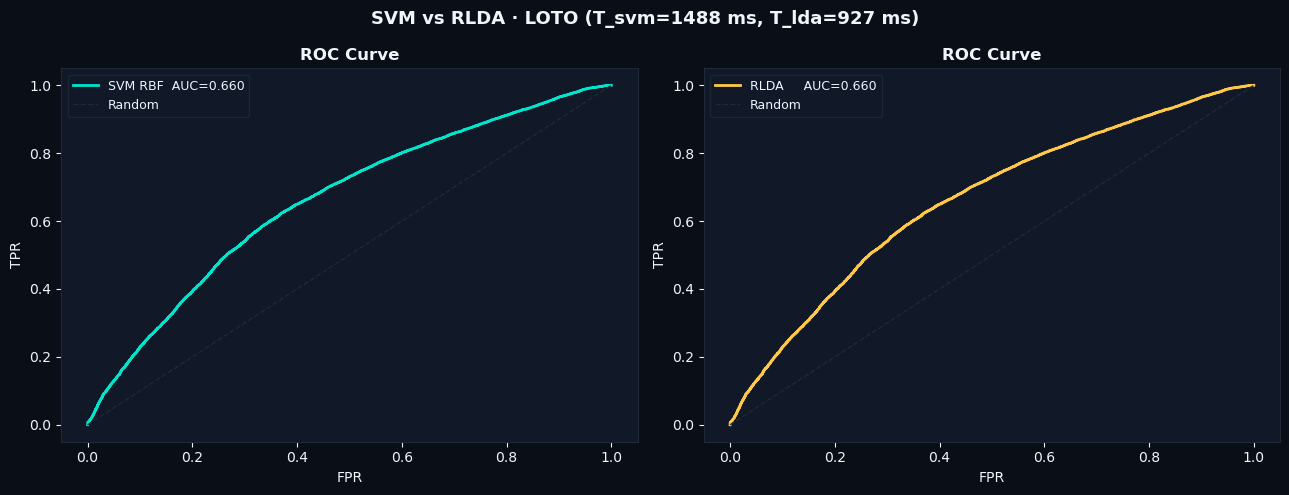

In [11]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=DARK)

for ax, (probs_s, y_p, auc_s, label, color) in zip(
    axes,
    [
        (svm_probs_s, y_pool, svm_auc_s, f"SVM RBF  AUC={svm_auc_s:.3f}", TEAL),
        (lda_probs_s, y_lda, lda_auc_s, f"RLDA     AUC={lda_auc_s:.3f}", GOLD),
    ],
):
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    fpr_, tpr_, _ = roc_curve(y_p, probs_s)
    ax.plot(fpr_, tpr_, color=color, lw=2, label=label)
    ax.plot([0, 1], [0, 1], color=EDGE, lw=1, ls="--", label="Random")
    ax.set_xlabel("FPR", color=WHITE)
    ax.set_ylabel("TPR", color=WHITE)
    ax.set_title("ROC Curve", color=WHITE, fontweight="bold")
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=9)

plt.suptitle(
    f"SVM vs RLDA · LOTO (T_svm={T_svm/FS_EFF*1000:.0f} ms, T_lda={T_lda/FS_EFF*1000:.0f} ms)",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 11 · Probability Timeline (one trial)

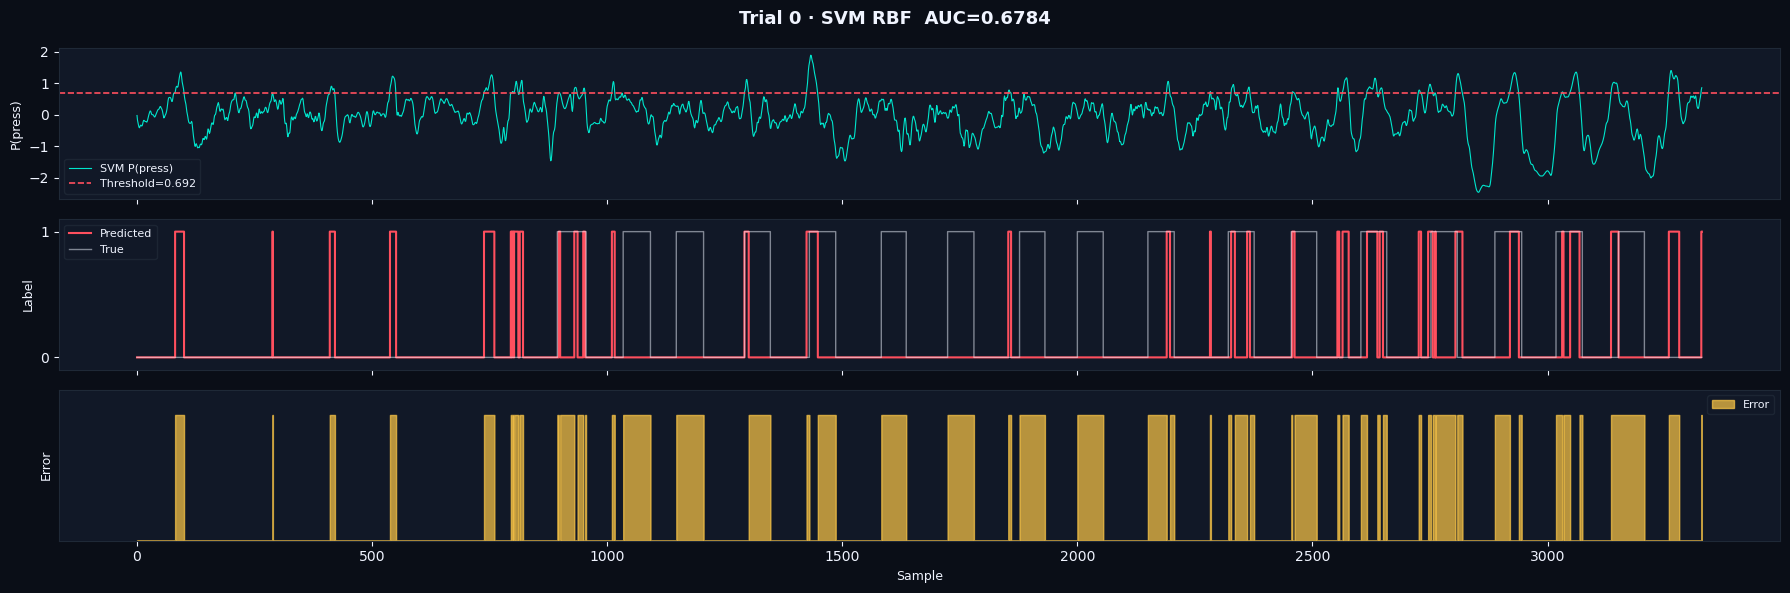

In [14]:
%matplotlib inline
SHOW_TRIAL = 0

mask_t = tid_pool == SHOW_TRIAL
probs_t = svm_probs[mask_t]
y_t = y_pool[mask_t]
preds_t = (probs_t >= svm_thresh).astype(int)

fig, axes = plt.subplots(3, 1, figsize=(18, 6), sharex=True, facecolor=DARK)
t_ax = np.arange(len(probs_t))

ax = axes[0]
ax.set_facecolor(CARD)
ax.plot(t_ax, probs_t, color=TEAL, lw=0.8, label="SVM P(press)")
ax.axhline(
    svm_thresh, color=CORAL, lw=1.2, ls="--", label=f"Threshold={svm_thresh:.3f}"
)
#ax.set_ylim(0, 1)
ax.set_ylabel("P(press)", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values():
    sp.set_color(EDGE)

ax = axes[1]
ax.set_facecolor(CARD)
ax.plot(t_ax, preds_t, drawstyle="steps-post", color=CORAL, lw=1.5, label="Predicted")
ax.plot(t_ax, y_t, drawstyle="steps-post", color=WHITE, lw=1.0, alpha=0.5, label="True")
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])
ax.set_ylabel("Label", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values():
    sp.set_color(EDGE)

ax = axes[2]
ax.set_facecolor(CARD)
errors = (preds_t != y_t).astype(float)
ax.fill_between(t_ax, errors, color=GOLD, alpha=0.7, step="post", label="Error")
ax.set_ylim(0, 1.2)
ax.set_yticks([])
ax.set_ylabel("Error", color=WHITE, fontsize=9)
ax.set_xlabel("Sample", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values():
    sp.set_color(EDGE)

fig.suptitle(
    f"Trial {SHOW_TRIAL} · SVM RBF  AUC={roc_auc_score(y_t, probs_t):.4f}",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()